###Aναστασία Λουκέρη 10975, Μαρία Ελένη Σαμαμίδου 11054
#ΜΕΡΟΣ Α - MAXIMUM LIKELIHOOD ESTIMATION

Το αρχείο φορτώθηκε.
Εκτιμώμενη μέση τιμή: [29.20903802 16.84988855]
Εκτιμώμενος πίνακας συνδιασποράς:
[[46.98591258 22.90532295]
 [22.90532295 48.63133559]]

Εκτιμώμενη μέση τιμή: [40.19766916 34.28109099]
Εκτιμώμενος πίνακας συνδιασποράς:
[[ 9.42390491 11.48971771]
 [11.48971771 20.10805596]]

Εκτιμώμενη μέση τιμή: [27.55232503 34.79318037]
Εκτιμώμενος πίνακας συνδιασποράς:
[[13.96874391 11.77433636]
 [11.77433636 25.28848192]]



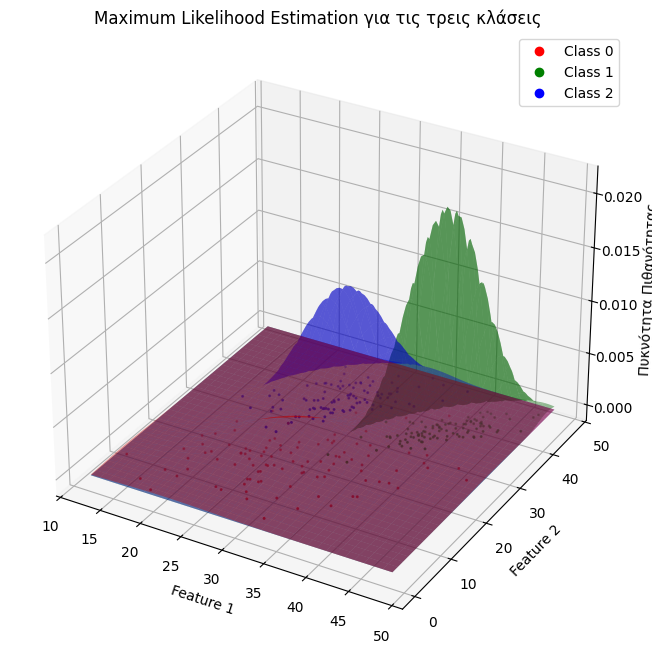

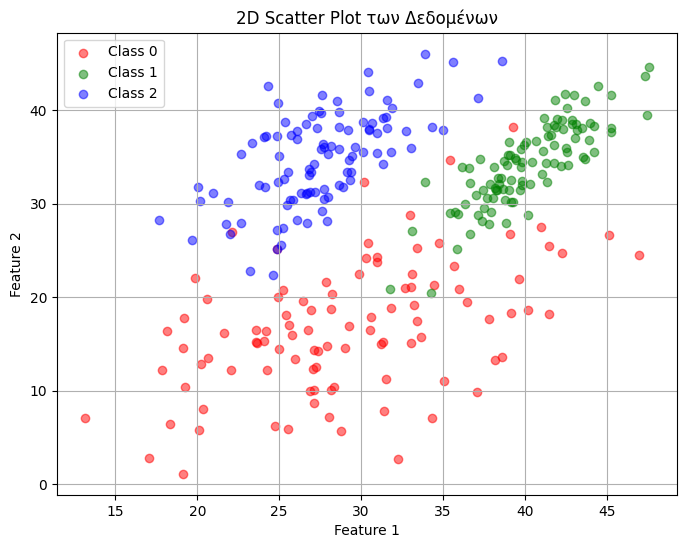

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


path = 'dataset1.csv'
# Φόρτωση
all_data = np.loadtxt(path, delimiter=',')
features = all_data[:, :2]
print("Το αρχείο φορτώθηκε.")


def calculate_mle_params(data):
    """
    Υπολογίζει τις παραμέτρους MLE (Μέση τιμή, Πίνακας Συνδιακύμανσης)
    για Κανονική Κατανομή
    """
    N = data.shape[0] # Αριθμός δειγμάτων

    #  Υπολογισμός Μέσης Τιμής
    # mean = (1/N) * Sum(x)
    mu = np.sum(data, axis=0) / N

    #  Υπολογισμός Πίνακα Συνδιακύμανσης (Covariance Matrix)
    # Sigma = (1/N) * Sum((x - mu) * (x - mu)^T)

    # Κεντράρουμε τα δεδομένα αφαιρώντας τη μέση τιμή
    data_centered = data - mu

    # Υπολογίζουμε το γινόμενο πινάκων.
    # Το data_centered.T @ data_centered κάνει το άθροισμα των γινομένων
    sigma = (data_centered.T @ data_centered) / N

    return mu, sigma

def multivariate_gaussian_pdf(X, mu, sigma):
    """
    Υπολογίζει την πυκνότητα πιθανότητας (PDF) για την πολυμεταβλητή
    κανονική κατανομή σε ένα σημείο ή σημεία X.
    f(x) = (1 / (sqrt((2pi)^k * |Sigma|))) * exp(-0.5 * (x-mu)^T * Sigma^-1 * (x-mu))
    """
    k = mu.shape[0] # Διάσταση (εδώ είναι 2)

    # Υπολογισμός ορίζουσας και αντίστροφου πίνακα συνδιακύμανσης
    sigma_det = np.linalg.det(sigma)
    sigma_inv = np.linalg.inv(sigma)

    # Κανονικοποιητικός παράγοντας (το κομμάτι πριν το exp)
    norm_const = 1.0 / (np.sqrt((2*np.pi)**k * sigma_det))

    # Υπολογισμός του εκθέτη για όλα τα σημεία X
    # Χρειάζεται προσοχή στις διαστάσεις για να γίνει σωστά το broadcasting
    X_centered = X - mu

    # Υπολογισμός του (x-mu)^T * Sigma^-1 * (x-mu)
    # Χρησιμοποιούμε einsum για γρήγορο υπολογισμό σε πολλά σημεία ταυτόχρονα
    exponent = -0.5 * np.einsum('...k,kl,...l->...', X_centered, sigma_inv, X_centered)

    return norm_const * np.exp(exponent)

class_0_data = features[0:100, :]
class_1_data = features[100:200, :]
class_2_data = features[200:300, :]

datasets = [class_0_data, class_1_data, class_2_data]
colors = ['red', 'green', 'blue']
labels = ['Class 0', 'Class 1', 'Class 2']

# Παραμετροι του maximum likelihood estimator
params = []
for ds in datasets:
    mu_est, sigma_est = calculate_mle_params(ds)
    params.append((mu_est, sigma_est))
    print(f"Εκτιμώμενη μέση τιμή: {mu_est}\nΕκτιμώμενος πίνακας συνδιασποράς:\n{sigma_est}\n")

# προετοιμασια 3d plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')


# Βρίσκουμε τα min/max για να καλύψουμε όλο τον χώρο
x_min, x_max = features[:, 0].min() - 1, features[:, 0].max() + 1
y_min, y_max = features[:, 1].min() - 1, features[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

# Μετατροπή του grid σε μορφή κατάλληλη για την συνάρτηση pdf (N x 2)
pos = np.dstack((xx, yy))

# Σχεδίαση
for i, (mu, sigma) in enumerate(params):
    # Υπολογισμός τιμών Z (πυκνότητα πιθανότητας) στο grid
    z = multivariate_gaussian_pdf(pos, mu, sigma)

    # Plot surface
    # Το alpha=0.5 κάνει τις καμπύλες ημιδιαφανείς για να φαίνονται όλες
    ax.plot_surface(xx, yy, z, rstride=3, cstride=3,
                    color=colors[i], alpha=0.4, label=labels[i])

    # Plot τα πραγματικά σημεία στο πάτωμα (z=0)
    ax.scatter(datasets[i][:,0], datasets[i][:,1], 0, c=colors[i], marker='.', s=5)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_zlabel('Πυκνότητα Πιθανότητας')
ax.set_title('Maximum Likelihood Estimation για τις τρεις κλάσεις')

# legend στο 3D plot
import matplotlib.lines as mlines
proxies = [mlines.Line2D([], [], color=c, marker='o', linestyle='None') for c in colors]
ax.legend(proxies, labels)

plt.show()
#Οπτικοποίηση δεδομενων
plt.figure(figsize=(8, 6))
plt.scatter(class_0_data[:, 0], class_0_data[:, 1], c='red', label='Class 0', alpha=0.5)
plt.scatter(class_1_data[:, 0], class_1_data[:, 1], c='green', label='Class 1', alpha=0.5)
plt.scatter(class_2_data[:, 0], class_2_data[:, 1], c='blue', label='Class 2', alpha=0.5)
plt.title("2D Scatter Plot των Δεδομένων")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()

#ΜΕΡΟΣ Β - ΠΑΡΑΘΥΡΑ PARZEN

Πλήθος δεδομένων: 200


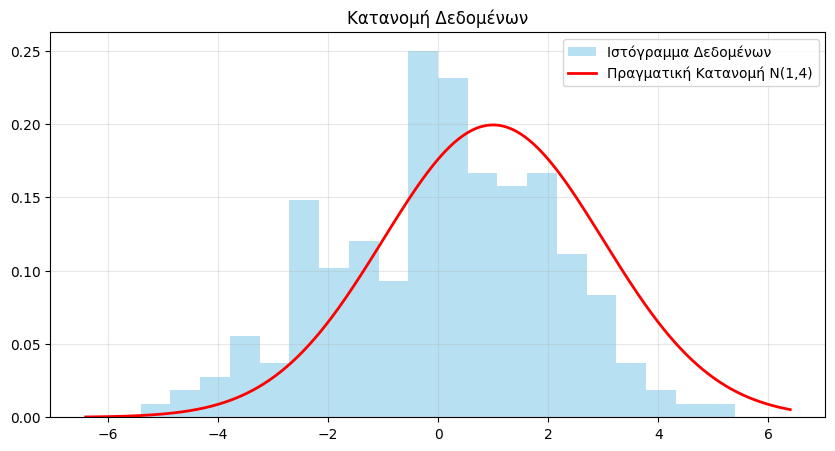

Βέλτιστο h για Υπερκύβο (Hypercube) kernel: 1.4 (Σφάλμα: 0.2145)
Βέλτιστο h για Γκαουσιανό (Gaussian) kernel: 0.8 (Σφάλμα: 0.2233)
Θεωρητικό h από τον κανόνα Silverman για Γκαουσιανό kernel: 0.7347


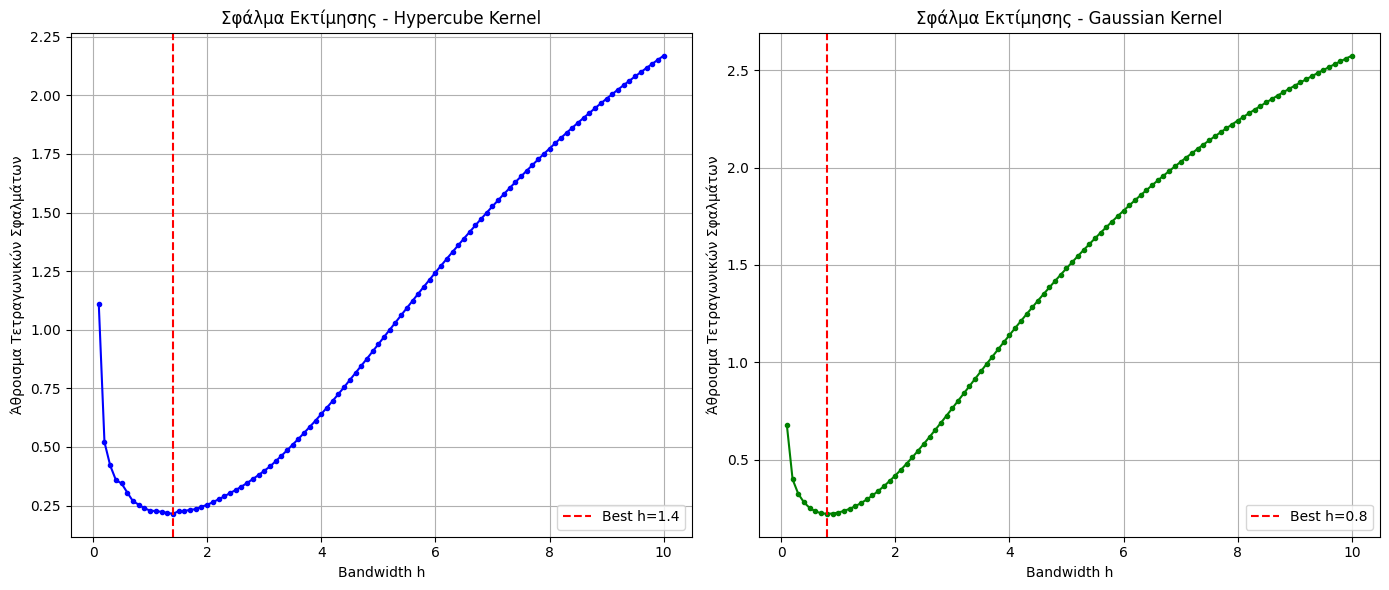

In [ ]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm



# Data Loading and Flattening
df = pd.read_csv('dataset2.csv', header=None)
data = df.values.flatten()



print(f"Πλήθος δεδομένων: {len(data)}")

# Histogram of data
plt.figure(figsize=(10, 5))
plt.hist(data, bins=20, density=True, alpha=0.6, color='skyblue', label='Ιστόγραμμα Δεδομένων')

# True PDF
x_axis = np.linspace(np.min(data)-1, np.max(data)+1, 500)
true_pdf_plot = norm.pdf(x_axis, loc=1, scale=2)
plt.plot(x_axis, true_pdf_plot, 'r-', linewidth=2, label='Πραγματική Κατανομή N(1,4)')

plt.title('Κατανομή Δεδομένων')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Parzen Windows and Kernel definitions

def hypercube_kernel(u):
    return np.where(np.abs(u) <= 1, 0.5, 0.0)

def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def parzen_predict_point(x, dataset, h, kernel_func):
    n = len(dataset)
    u = (x - dataset) / h
    return np.sum(kernel_func(u)) / (n * h)

# Error calculation across different values of h
h_values = np.arange(0.1, 10.1, 0.1)
errors_hypercube = []
errors_gaussian = []

# Ground Truth of the given data
true_likelihoods = norm.pdf(data, loc=1, scale=2)

for h in h_values:
    # Hypercube
    preds_hyp = np.array([parzen_predict_point(xi, data, h, hypercube_kernel) for xi in data])
    # Sum of squared errors
    sq_error_hyp = np.sum((preds_hyp - true_likelihoods) ** 2)
    errors_hypercube.append(sq_error_hyp)

    # Gaussian
    preds_gauss = np.array([parzen_predict_point(xi, data, h, gaussian_kernel) for xi in data])
    sq_error_gauss = np.sum((preds_gauss - true_likelihoods) ** 2)
    errors_gaussian.append(sq_error_gauss)

# Optimal h and min error indexing
min_idx_hyp = np.argmin(errors_hypercube)
min_idx_gauss = np.argmin(errors_gaussian)

best_h_hyp = h_values[min_idx_hyp]
best_h_gauss = h_values[min_idx_gauss]


print(f"Βέλτιστο h για Υπερκύβο (Hypercube) kernel: {best_h_hyp:.1f} (Σφάλμα: {errors_hypercube[min_idx_hyp]:.4f})")
print(f"Βέλτιστο h για Γκαουσιανό (Gaussian) kernel: {best_h_gauss:.1f} (Σφάλμα: {errors_gaussian[min_idx_gauss]:.4f})")
silverman_h = 1.06 * 2 * (200 ** (-1/5))
print(f"Θεωρητικό h από τον κανόνα Silverman για Γκαουσιανό kernel: {silverman_h:.4f}")



# Plots


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Hypercube
ax1.plot(h_values, errors_hypercube, 'b.-')
ax1.axvline(best_h_hyp, color='red', linestyle='--', label=f'Best h={best_h_hyp:.1f}')
ax1.set_title('Σφάλμα Εκτίμησης - Hypercube Kernel')
ax1.set_xlabel('Bandwidth h')
ax1.set_ylabel('Άθροισμα Τετραγωνικών Σφαλμάτων')
ax1.legend()
ax1.grid(True)

# Plot Gaussian
ax2.plot(h_values, errors_gaussian, 'g.-')
ax2.axvline(best_h_gauss, color='red', linestyle='--', label=f'Best h={best_h_gauss:.1f}')
ax2.set_title('Σφάλμα Εκτίμησης - Gaussian Kernel')
ax2.set_xlabel('Bandwidth h')
ax2.set_ylabel('Άθροισμα Τετραγωνικών Σφαλμάτων')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

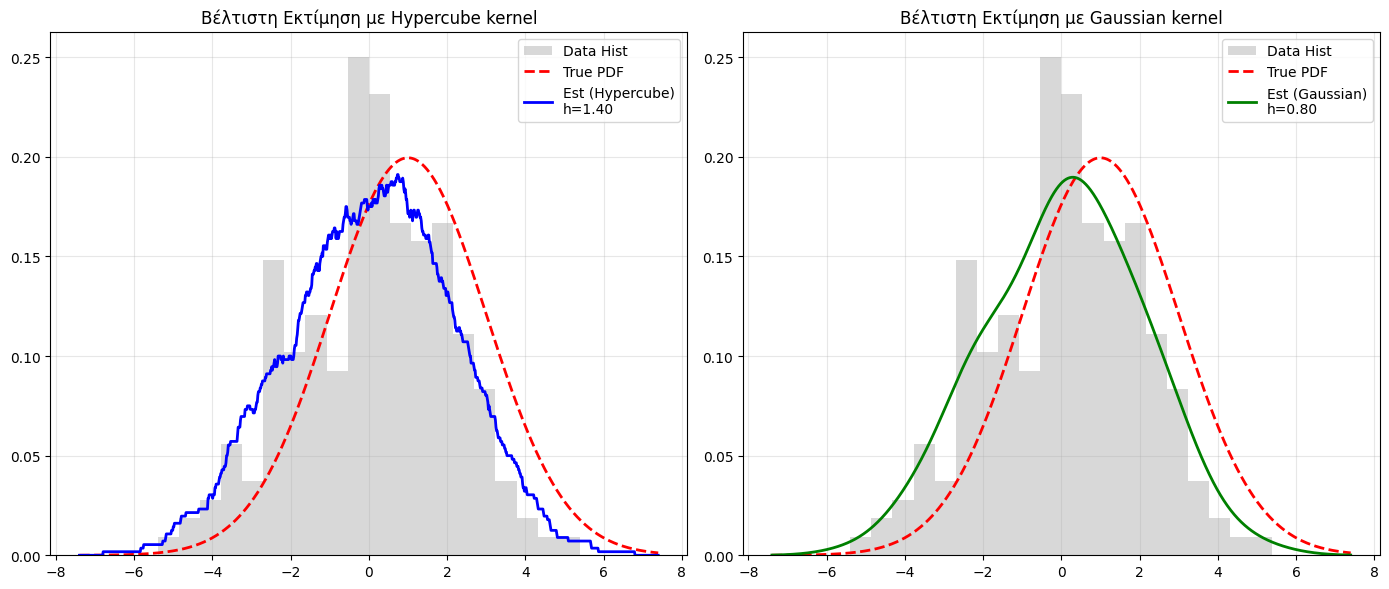

In [ ]:
# Distribution Visualization
x_grid = np.linspace(np.min(data) - 2, np.max(data) + 2, 1000)

# True PDF
true_pdf_grid = norm.pdf(x_grid, loc=1, scale=2)

# Parzen Windows Estimation for hypercube kernel
est_pdf_hyp = np.array([parzen_predict_point(x, data, best_h_hyp, hypercube_kernel) for x in x_grid])

# Parzen Windows Estimation for gaussian kernel
est_pdf_gauss = np.array([parzen_predict_point(x, data, best_h_gauss, gaussian_kernel) for x in x_grid])

# Plots
plt.figure(figsize=(14, 6))

# Hypercube kernel
plt.subplot(1, 2, 1)
# Histogram
plt.hist(data, bins=20, density=True, alpha=0.3, color='gray', label='Data Hist')
# True PDF
plt.plot(x_grid, true_pdf_grid, 'r--', linewidth=2, label='True PDF')
# Estimation
plt.plot(x_grid, est_pdf_hyp, 'b-', linewidth=2, label=f'Est (Hypercube)\nh={best_h_hyp:.2f}')

plt.title('Βέλτιστη Εκτίμηση με Hypercube kernel')
plt.legend()
plt.grid(True, alpha=0.3)

# Gaussian Kernel
plt.subplot(1, 2, 2)
# Histogram
plt.hist(data, bins=20, density=True, alpha=0.3, color='gray', label='Data Hist')
# True PDF
plt.plot(x_grid, true_pdf_grid, 'r--', linewidth=2, label='True PDF')
# Estimation
plt.plot(x_grid, est_pdf_gauss, 'g-', linewidth=2, label=f'Est (Gaussian)\nh={best_h_gauss:.2f}')
plt.title('Βέλτιστη Εκτίμηση με Gaussian kernel')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#ΜΕΡΟΣ Γ - k Nearest Neighbors from scratch

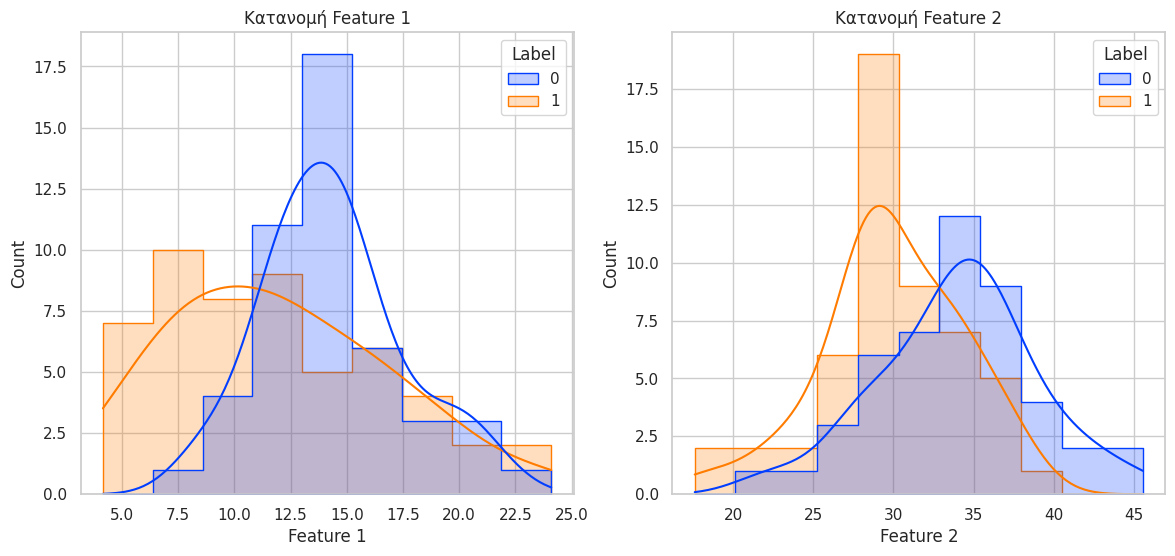

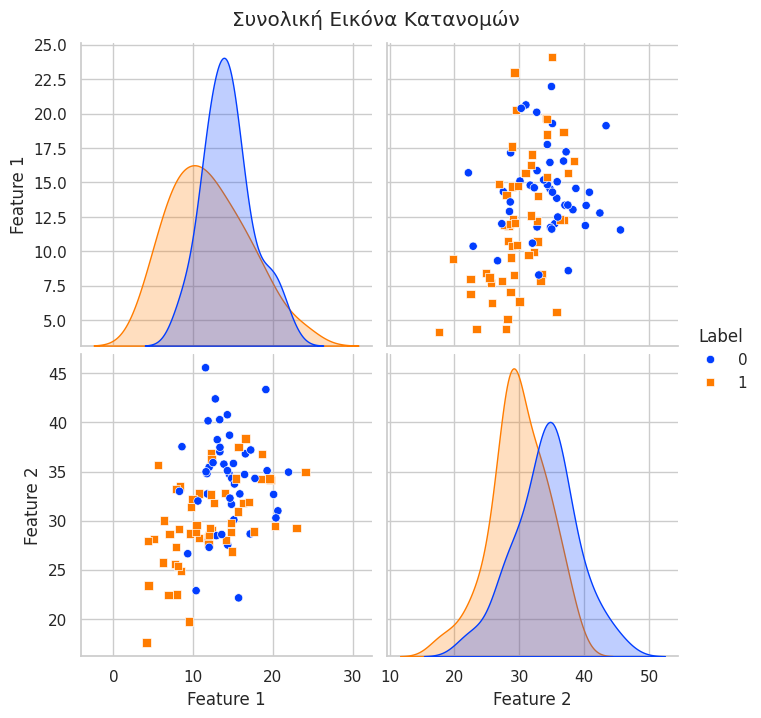

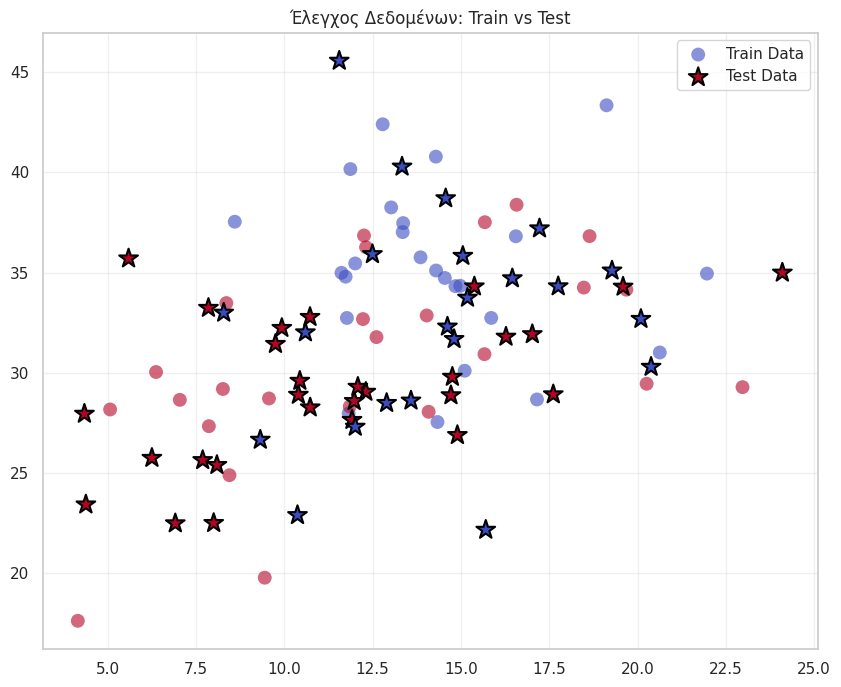

Τα δεδομένα φορτώθηκαν επιτυχώς.
Train set: (50, 3), Test set: (50, 3)

Υπολογισμός ακρίβειας για k = 1 έως 30...
--> Βέλτιστο k: 11 με Ακρίβεια: 0.74 (74.0%)


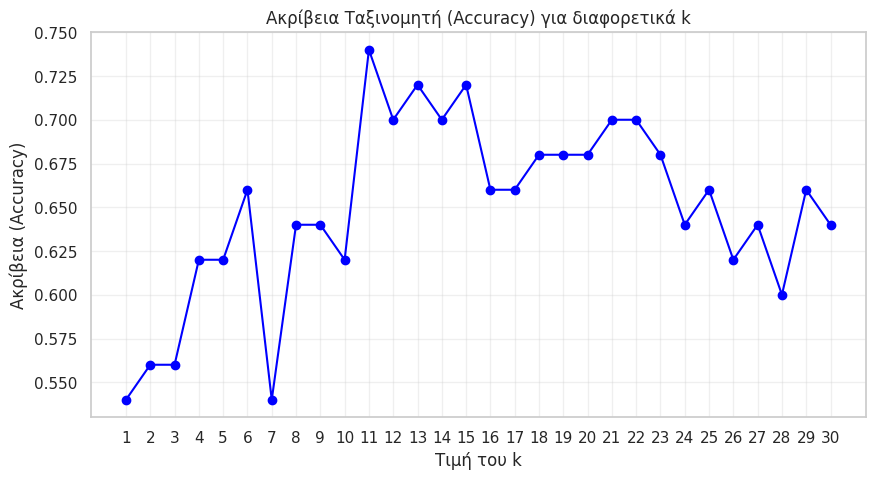


Σχεδίαση ορίων απόφασης για k=11...


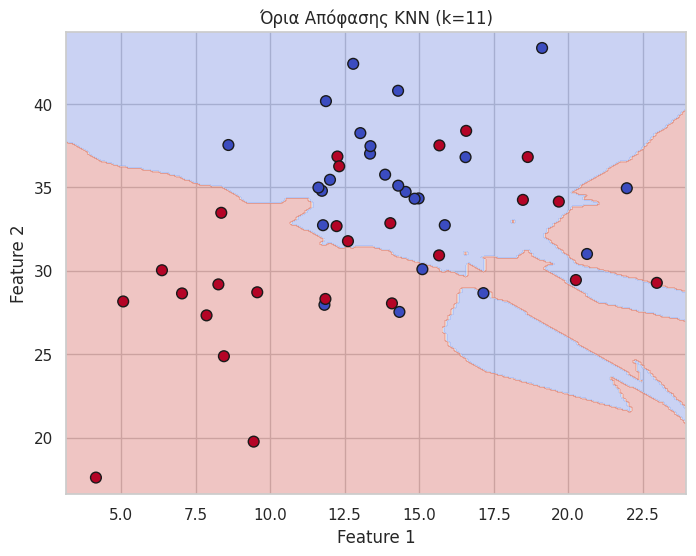

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Loading
train = pd.read_csv('dataset3.csv', header=None).values
test = pd.read_csv('testset.csv', header=None).values
all_data = np.vstack((train, test))

# Dataframe
df = pd.DataFrame(all_data, columns=['Feature 1', 'Feature 2', 'Label'])
df['Label'] = df['Label'].astype(int).astype(str)


sns.set(style="whitegrid")

# Data Distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Feature 1
sns.histplot(data=df, x='Feature 1', hue='Label', kde=True, element="step", ax=axes[0], palette='bright')
axes[0].set_title('Κατανομή Feature 1')

# Feature 2
sns.histplot(data=df, x='Feature 2', hue='Label', kde=True, element="step", ax=axes[1], palette='bright')
axes[1].set_title('Κατανομή Feature 2')

plt.show()

#Image of histograms with density curves showing overlapping distributions

# scatter plot  of data points and distributiions
sns.pairplot(df, hue='Label', palette='bright', markers=["o", "s"], height=3.5)
plt.suptitle("Συνολική Εικόνα Κατανομών", y=1.02)
plt.show()
train = pd.read_csv('dataset3.csv', header=None).values
test = pd.read_csv('testset.csv', header=None).values

# Plot of the train and test data in order to check how they "overlap"
plt.figure(figsize=(10, 8))

# Train Set
plt.scatter(train[:, 0], train[:, 1], c=train[:, -1], cmap='coolwarm',
            label='Train Data', alpha=0.6, s=100, edgecolors='none')

#  Test Set

plt.scatter(test[:, 0], test[:, 1], c=test[:, -1], cmap='coolwarm',
            marker='*', s=200, label='Test Data', edgecolors='black', linewidths=1.5)

plt.title("Έλεγχος Δεδομένων: Train vs Test")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
# Data Loading

train_df = pd.read_csv('dataset3.csv', header=None)
test_df = pd.read_csv('testset.csv', header=None)

# Convert to numpy arrays for handling
trainData = train_df.values
testData = test_df.values
print("Τα δεδομένα φορτώθηκαν επιτυχώς.")
print(f"Train set: {trainData.shape}, Test set: {testData.shape}")



# Functions

def eucl(x, trainData):
    features = trainData[:, :-1]

    # Vectorized distance calculation: sqrt(sum((x-y)^2))
    diff = features - x
    dists = np.sqrt(np.sum(diff**2, axis=1))
    return dists

def neighbors(x, trainData, k):
    # Distance Calculation
    dists = eucl(x, trainData)

    # Classification
    sorted_indices = np.argsort(dists)
    top_k_indices = sorted_indices[:k]
    return trainData[top_k_indices]

def predict(testData, trainData, k):
    probabilities = []

    for row in testData:
        x = row[:-1] # FEatures

        # K nearest Neighbors
        k_nn = neighbors(x, trainData, k)

        # Labels in the last columnt
        neighbor_labels = k_nn[:, -1]

        # Prob calculation
        count_0 = np.sum(neighbor_labels == 0)
        count_1 = np.sum(neighbor_labels == 1)

        prob_0 = count_0 / k
        prob_1 = count_1 / k

        probabilities.append([prob_0, prob_1])

    return np.array(probabilities)

# Optimal K with Cross Validation in the test set
print("\nΥπολογισμός ακρίβειας για k = 1 έως 30...")

accuracies = []
k_range = range(1, 31)
actual_labels = testData[:, -1]

for k in k_range:
    # Probabilities
    probs = predict(testData, trainData, k)

    # if prob_1 > prob_0 then we classify as 1 else 0
    # index of max prob
    predictions = np.argmax(probs, axis=1)

    # Accuracy calculation
    accuracy = np.mean(predictions == actual_labels)
    accuracies.append(accuracy)

# Optimal K
best_accuracy = max(accuracies)
# if more than a specific k gives the same accuracy, we choose the one with the smallest cvalue
best_k = k_range[accuracies.index(best_accuracy)]

print(f"--> Βέλτιστο k: {best_k} με Ακρίβεια: {best_accuracy:.2f} ({best_accuracy*100}%)")

# PLots
plt.figure(figsize=(10, 5))
plt.plot(k_range, accuracies, marker='o', color='blue', linestyle='-')
plt.title('Ακρίβεια Ταξινομητή (Accuracy) για διαφορετικά k')
plt.xlabel('Τιμή του k')
plt.ylabel('Ακρίβεια (Accuracy)')
plt.xticks(k_range)
plt.grid(True, alpha=0.3)
plt.show()



# Decision Boundary
print(f"\nΣχεδίαση ορίων απόφασης για k={best_k}...")

# mesh plot
x_min, x_max = trainData[:, 0].min() - 1, trainData[:, 0].max() + 1
y_min, y_max = trainData[:, 1].min() - 1, trainData[:, 1].max() + 1
h = 0.1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

grid_points = np.c_[xx.ravel(), yy.ravel()]
grid_input = np.hstack((grid_points, np.zeros((grid_points.shape[0], 1))))

# Prediction
probs_grid = predict(grid_input, trainData, best_k)
Z = np.argmax(probs_grid, axis=1)
Z = Z.reshape(xx.shape)
plt.figure(figsize=(8, 6))

plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.coolwarm)
plt.scatter(trainData[:, 0], trainData[:, 1], c=trainData[:, -1],
            cmap=plt.cm.coolwarm, edgecolors='k', s=60)

plt.title(f'Όρια Απόφασης KNN (k={best_k})')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()